In [130]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import statsmodels.api as sm

In [131]:
cotacoes = pd.read_excel('economatica(3).xlsx', header = 3, index_col=0, na_values = ['-'])
nomes_novos = []
for cotacao in cotacoes.columns:
    nomes_novos.append(cotacao.split("\n")[-1])
cotacoes.columns = nomes_novos

selic = pd.read_excel('Selic.xlsx', header = 3, index_col=0, na_values = ['-'])
selic.columns = ['SELIC']

dados = pd.concat([cotacoes, selic], axis=1)
dados = dados.dropna()
retornos_simples = dados.pct_change().dropna()

In [132]:
y = retornos_simples['PETR4']
x = sm.add_constant(retornos_simples['SELIC'])
modelo = sm.OLS(y, x).fit()
# Poderia haver uma relação inversa entre a SELIC e os retornos da PETR4, visto que quando a SELIC aumenta, o custo de oportunidade do investimento em ações aumenta, levando os investidores a preferirem investimentos mais seguros, como títulos públicos.

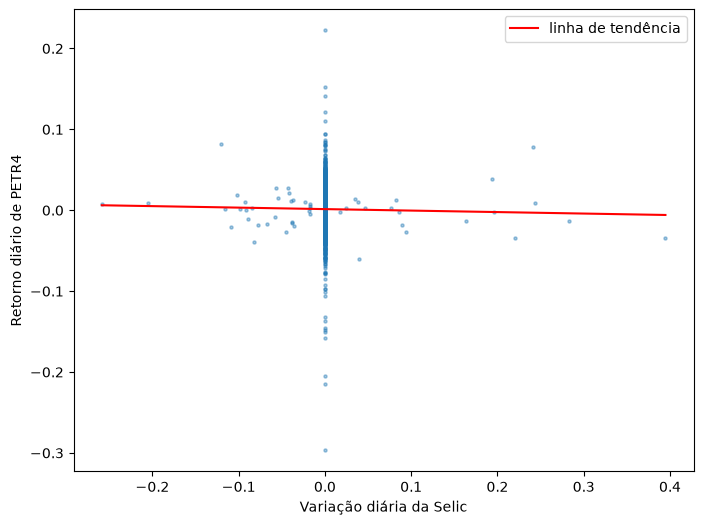

In [133]:
alfa = modelo.params["const"]
beta = modelo.params["SELIC"]
x = np.linspace(retornos_simples["SELIC"].min(), retornos_simples["SELIC"].max(), 100)

plt.figure(figsize=(8, 6))
plt.scatter(retornos_simples["SELIC"], retornos_simples["PETR4"], s=5, alpha=0.4)      # um ponto por dia
plt.plot(x, alfa + beta * x, color="red", label="linha de tendência")
plt.xlabel("Variação diária da Selic")
plt.ylabel("Retorno diário de PETR4")
plt.legend()
plt.show()

# O gráfico mostra que a relação entre a SELIC e PETR4 é negativa, confirmando a hipótese, porém muito fraco, já que, em dias de decisão do COPOM, PETR4 sobe e cai

In [134]:
print(modelo.summary())
# O valor do coeficiente é negativo (coeficiente da selic = -0,0184), o que condiz com minha hipótese inicial.
# O valor do coeficiente não é significante a 5%, visto que o p-valor é 0,52.
# O R quadrado da regressão indica a parcela da variação de PETR4 que é explicada pela variação da SELIC, como o resultado é 0, a variação da SELIC não afeta PETR4.

                            OLS Regression Results                            
Dep. Variable:                  PETR4   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.4093
Date:                Tue, 06 Oct 2026   Prob (F-statistic):              0.522
Time:                        12:34:58   Log-Likelihood:                 5439.4
No. Observations:                2419   AIC:                        -1.087e+04
Df Residuals:                    2417   BIC:                        -1.086e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0014      0.001      2.760      0.0

In [135]:
previsao_1 = modelo.predict([1, 0.01])
print(previsao_1)
previsao_5 = modelo.predict([1, 0.05])
print(previsao_5)
previsao_10 = modelo.predict([1, 0.1])
print(previsao_10)
previsao_30 = modelo.predict([1, 0.30])
print(previsao_30)

[0.00125024]
[0.00051573]
[-0.00040241]
[-0.00407498]


In [136]:
# Utilizando somente uma variável preditora, o viés mais provável é o de variável omitida.
dolar = pd.read_excel("Dolar.xlsx", header = 3, index_col= 0, na_values=['-'])
dolar.columns = ["DOLAR"]
dados2 = pd.concat([cotacoes, selic, dolar], axis= 1)
dados2 = dados2.dropna()
retornos_simples2= dados2.pct_change().dropna()
x_2 = sm.add_constant(retornos_simples2[["SELIC", "DOLAR"]])
modelo2 = sm.OLS(retornos_simples2['PETR4'], x_2).fit()
print(modelo2.summary())

# No modelo 2, o R quadrado aumentou em relação ao modelo 1 (0,065 > 0). Dessa forma, a variação da SELIC e do dólar explica 6,5% da variação em PETR4.
# Além disso, a SELIC passa a ter uma relação mais negativa com PETR4 (-0,047 < -0,0184), indicando que a adição do dólar no modelo trouxe uma nova relação entre PETR4 e SELIC.
# Por fim, o dólar apresenta forte relação negativa com PETR4 (-0,76), ou seja, a cada 1% de variação no dólar, PETR4 varia -0,76% em média.

                            OLS Regression Results                            
Dep. Variable:                  PETR4   R-squared:                       0.065
Model:                            OLS   Adj. R-squared:                  0.065
Method:                 Least Squares   F-statistic:                     84.56
Date:                Tue, 06 Oct 2026   Prob (F-statistic):           3.19e-36
Time:                        12:34:58   Log-Likelihood:                 5521.0
No. Observations:                2419   AIC:                        -1.104e+04
Df Residuals:                    2416   BIC:                        -1.102e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0016      0.001      3.210      0.0

In [137]:
portfolio = pd.read_csv('ret_portfolio.xlsx', index_col= 0, parse_dates= True).iloc[:, 0].rename("Portfolio")
dados3 = pd.concat([portfolio, retornos_simples["IBOV"]], axis = 1).dropna()
modelo_3 = sm.OLS(dados3["Portfolio"], sm.add_constant(dados3["IBOV"])).fit()
print(modelo_3.summary())
# O coeficiente, nesse caso, é o beta de mercado, ou seja, mede o risco sistemático do portfolio (variação do ativo devido a variação do mercado como um todo). Como beta = 1,16, o portfolio é mais volátil do que o mercado.

                            OLS Regression Results                            
Dep. Variable:              Portfolio   R-squared:                       0.640
Model:                            OLS   Adj. R-squared:                  0.640
Method:                 Least Squares   F-statistic:                     4302.
Date:                Tue, 06 Oct 2026   Prob (F-statistic):               0.00
Time:                        12:34:58   Log-Likelihood:                 7187.8
No. Observations:                2419   AIC:                        -1.437e+04
Df Residuals:                    2417   BIC:                        -1.436e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0006      0.000      2.385      0.0